# Day 3 · Cost-sensitive decision

In [1]:
from pathlib import Path
import hashlib, importlib.util, os, runpy, sys, time, urllib.request, urllib.error

RUN_STARTED = time.perf_counter()
COURSE_REVISION = "fe0c0204e6076a7ac2139b7336485a097343fb8a"
MANIFEST_SHA256 = "86d15e813caf833b7d86512808176388d4123dc3c01c6525ee849a76e8322c59"
SETUP_SHA256 = "79608f8f9559d9e6eb09d51ee541ee12d7e9262ac57d1ca3a948c8ecb14f0f35"
IN_COLAB = importlib.util.find_spec("google") is not None and importlib.util.find_spec("google.colab") is not None
ROOT = Path("/content/tamweel") if IN_COLAB else Path(os.environ.get("TAMWEEL_PROJECT_DIR", ".")).resolve()
setup_path = ROOT / "scripts/setup_colab.py"
setup_path.parent.mkdir(parents=True, exist_ok=True)
if not setup_path.exists() or hashlib.sha256(setup_path.read_bytes()).hexdigest() != SETUP_SHA256:
    setup_url = f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{COURSE_REVISION}/scripts/setup_colab.py"
    for attempt in range(3):
        try:
            with urllib.request.urlopen(setup_url, timeout=45) as response:
                setup_bytes = response.read(200000)
            if hashlib.sha256(setup_bytes).hexdigest() != SETUP_SHA256:
                raise ValueError("Setup checksum mismatch. Reopen the released notebook.")
            setup_path.write_bytes(setup_bytes)
            break
        except (urllib.error.URLError, TimeoutError):
            if attempt == 2:
                raise RuntimeError("Download unavailable. Retry setup or upload the unchanged project files; see READINESS_GUIDE.")
            time.sleep(attempt + 1)
environment = runpy.run_path(str(setup_path))["prepare"](ROOT, COURSE_REVISION, MANIFEST_SHA256)
FAST_MODE, FULL_MODE, SEED, N_JOBS = True, False, 211, 2

from setup_colab import fetch_verified
DAY2_REVISION = "1e1da4acbee8941bef07245b259fb6c27ced4ad7"
DAY2_SHA256 = "d2fd0353330c3629bdaed6c570528792955fce232540a85d33532a9432522f43"
fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{DAY2_REVISION}/scripts/day2_validation.py",
               ROOT / "scripts/day2_validation.py", DAY2_SHA256)
LAB_REVISION = "c2dc52e129878d0d487db1874891c658de7c4d0d"
SUPPORT_HASHES = {'scripts/day3_decision.py': '40f176633c91fc530db222978bc44495a401b888b1ce448728948f7ae0ca9e12', 'data/day3_oof_example.csv': '659952bef85ac3b7ceb7ab84eb2102de6c9b433a1ba122cd57df96581baf0eb3', 'data/day3_oof_example.json': '920cf9830043afcc83f8c276c8945677296eb3c49a6e69326d47f6080a9e7fad'}
for relative, digest in SUPPORT_HASHES.items():
    fetch_verified(f"https://raw.githubusercontent.com/almiyead-rgb/sda-dsc-211-student-template/{LAB_REVISION}/{relative}",
                   ROOT / relative, digest)
print("Day 3 setup verified | إعداد اليوم الثالث جاهز")

Package                 Version
numpy                   2.1.3
pandas                  2.2.3
scipy                   1.16.3
scikit-learn            1.6.1
matplotlib              3.10.0
xgboost                 3.4.1
lightgbm                4.6.0
shap                    0.52.0
numba                   0.61.2
optuna                  4.5.0
Python 3.13.16 | CPU | seed=211 | n_jobs=2 | FAST_MODE=True
Verified course files. Next: run the data and compatibility checks.
Day 3 setup verified | إعداد اليوم الثالث جاهز


In [2]:
import json, platform, zipfile
from dataclasses import asdict, replace
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from IPython.display import display
from data_checks import validate_frame
from day2_validation import deduplicate_applications, make_time_group_split
from day3_decision import (STRATEGIES, TARGET, DecisionConfig, CostPolicy, generate_oof,
    validate_oof, threshold_sweep, select_threshold, flag_at, period_audit, region_audit,
    reflection_check, load_example, TrainingBudgetExpired)

contract = json.loads((ROOT / "data/data_contract.json").read_text(encoding="utf-8"))
train, duplicates = deduplicate_applications(pd.read_csv(ROOT / "data/tamweel_train.csv"))
validate_frame(train, contract, "train")
FAST_MODE, FULL_MODE = True, False
assert FAST_MODE != FULL_MODE
config = DecisionConfig(trees=80 if FAST_MODE else 160)
policy = CostPolicy(**contract["decision_policy"])
MODEL_FOR_DECISION = "weighted"  # Declared before comparison; not a claim of superiority.
USE_EXAMPLE = False  # True is discussion only, never your submission.
ASSESSMENT_MODE = os.environ.get("ASSESSMENT_MODE", "0") == "1"
assert MODEL_FOR_DECISION in STRATEGIES
ARTIFACTS, REPORTS = ROOT / "artifacts", ROOT / "reports"
ARTIFACTS.mkdir(exist_ok=True); REPORTS.mkdir(exist_ok=True)
folds = make_time_group_split(train, horizon_days=contract["target"]["horizon_days"])
display(pd.DataFrame([{"training_rows": len(train), "positive_rate": train[TARGET].mean(),
    "FN_loss_units": policy.false_negative_cost, "FP_loss_units": policy.false_positive_cost,
    "period_capacity_fraction": policy.max_flag_fraction, "trees_per_model": config.trees}]))
display(pd.DataFrame([fold["audit"] for fold in folds]))

,training_rows,positive_rate,FN_loss_units,FP_loss_units,period_capacity_fraction,trees_per_model
0,10000,0.0789,10,1,0.12,80


,fold,validation_start,validation_end_exclusive,train_rows,validation_rows,train_positives,validation_positives,immature_past_rows_removed,customer_overlap_rows_removed,shared_customers,latest_training_label_available
0,1,2023-07-01,2024-01-01,3223,1632,274,110,826,912,0,2023-06-30
1,2,2024-01-01,2024-07-01,4460,1674,353,135,785,1348,0,2023-12-31
2,3,2024-07-01,2025-01-01,5731,1733,465,139,861,1675,0,2024-06-30


In [3]:
fallback_reason = None
if not USE_EXAMPLE:
    try:
        oof, model_report, provenance = generate_oof(train, contract, config)
    except TrainingBudgetExpired as exc:
        if ASSESSMENT_MODE:
            raise
        USE_EXAMPLE, fallback_reason = True, str(exc)
if USE_EXAMPLE:
    oof, example_info = load_example(ROOT / "data/day3_oof_example.csv",
        ROOT / "data/day3_oof_example.json", train, folds, assessment_mode=ASSESSMENT_MODE)
    model_report = pd.DataFrame(example_info["model_report"])
    provenance = {"source": "EDUCATIONAL_EXAMPLE", "example_metadata": example_info,
                  "fallback_reason": fallback_reason or "Learner selected discussion example"}
SOURCE = oof.source.iloc[0]
effective_config = example_info["config"] if USE_EXAMPLE else asdict(config)
coverage = validate_oof(oof, train, folds)
print("LIVE — your CPU run" if SOURCE == "LIVE" else
      "EDUCATIONAL_EXAMPLE — discussion only; EXAMPLE_ONLY_NOT_SUBMITTABLE")
display(pd.DataFrame([coverage]))
display(model_report[["strategy", "fold", "original_training_rows", "fitted_rows",
    "scale_pos_weight", "training_positive_rate", "fitted_positive_rate", "average_precision",
    "train_seconds", "source"]].round(4))
selected = oof[oof.strategy.eq(MODEL_FOR_DECISION)].copy()
assert selected.application_id.is_unique
print(f"Decision strategy declared before comparison: {MODEL_FOR_DECISION}")

LIVE — your CPU run


,eligible_rows,all_rows,whole_data_coverage,eligible_coverage,warmup_without_oof,source
0,5039,10000,0.5039,1.0,4961,LIVE


,strategy,fold,original_training_rows,fitted_rows,scale_pos_weight,training_positive_rate,fitted_positive_rate,average_precision,train_seconds,source
0,unweighted,1,3223,3223,1.0000,0.0850,0.0850,0.3395,0.4136,LIVE
1,weighted,1,3223,3223,10.7628,0.0850,0.0850,0.3378,0.0951,LIVE
2,oversampled,1,3223,5898,1.0000,0.0850,0.5000,0.3502,0.1269,LIVE
3,unweighted,2,4460,4460,1.0000,0.0791,0.0791,0.3403,0.1067,LIVE
4,weighted,2,4460,4460,11.6346,0.0791,0.0791,0.3295,0.1076,LIVE
5,oversampled,2,4460,8214,1.0000,0.0791,0.5000,0.3390,0.1854,LIVE
6,unweighted,3,5731,5731,1.0000,0.0811,0.0811,0.2661,0.4184,LIVE
7,weighted,3,5731,5731,11.3247,0.0811,0.0811,0.2707,0.1389,LIVE
8,oversampled,3,5731,10532,1.0000,0.0811,0.5000,0.2776,0.1904,LIVE


Decision strategy declared before comparison: weighted


,strategy,rows,positive_rate,pooled_roc_auc,pooled_ap,accuracy_at_0_5,recall_at_0_5,precision_at_0_5,flags_at_0_5,loss_at_0_5,capacity_ok_at_0_5,source
0,unweighted,5039,0.0762,0.7979,0.3091,0.9256,0.1250,0.5517,87,3399,True,LIVE
1,weighted,5039,0.0762,0.7969,0.3100,0.8125,0.5781,0.2209,1005,2403,False,LIVE
2,oversampled,5039,0.0762,0.7979,0.3159,0.8073,0.5990,0.2197,1047,2357,False,LIVE


,rule,rows,accuracy,recall,precision,loss_units
0,No flags for anyone,5039,0.923794,0.0,None,3840


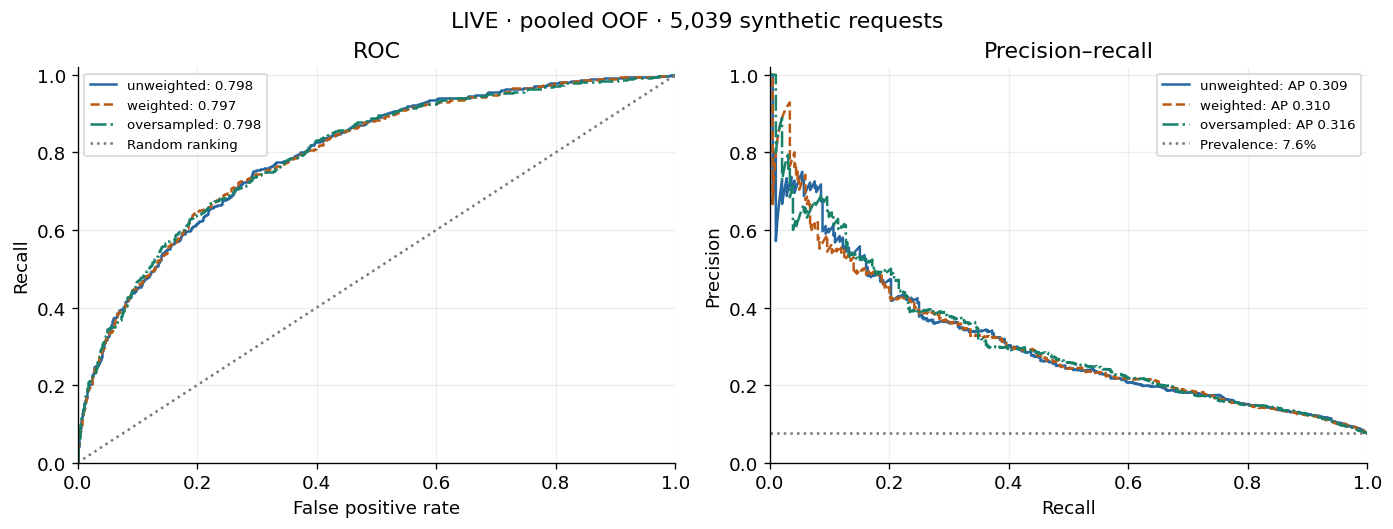

In [4]:
comparison_rows = []
for strategy, group in oof.groupby("strategy", sort=False):
    sweep = threshold_sweep(group, policy)
    default = sweep.loc[sweep.threshold.eq(.5)].iloc[0]
    comparison_rows.append({"strategy": strategy, "rows": len(group), "positive_rate": group[TARGET].mean(),
        "pooled_roc_auc": roc_auc_score(group[TARGET], group.probability),
        "pooled_ap": average_precision_score(group[TARGET], group.probability),
        "accuracy_at_0_5": default.accuracy, "recall_at_0_5": default.recall,
        "precision_at_0_5": default.precision, "flags_at_0_5": default.flagged,
        "loss_at_0_5": default.loss_units, "capacity_ok_at_0_5": default.capacity_feasible, "source": SOURCE})
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(4))
no_flag_reference = {"rule": "No flags for anyone", "rows": len(selected),
    "accuracy": 1-selected[TARGET].mean(), "recall": 0., "precision": None,
    "loss_units": int(selected[TARGET].sum()) * policy.false_negative_cost}
display(pd.DataFrame([no_flag_reference]))

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 120, "axes.grid": True, "grid.alpha": .2})
colors = {"unweighted": "#2667A0", "weighted": "#BA5A17", "oversampled": "#18816A"}
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3), constrained_layout=True)
for strategy, style in zip(STRATEGIES, ["-", "--", "-."]):
    group = oof[oof.strategy.eq(strategy)]
    fpr, tpr, _ = roc_curve(group[TARGET], group.probability)
    precision, recall, _ = precision_recall_curve(group[TARGET], group.probability)
    row = comparison.set_index("strategy").loc[strategy]
    axes[0].plot(fpr, tpr, color=colors[strategy], linestyle=style, label=f"{strategy}: {row.pooled_roc_auc:.3f}")
    axes[1].plot(recall, precision, color=colors[strategy], linestyle=style, label=f"{strategy}: AP {row.pooled_ap:.3f}")
axes[0].plot([0,1], [0,1], color="#777777", linestyle=":", label="Random ranking")
axes[1].axhline(selected[TARGET].mean(), color="#777777", linestyle=":", label=f"Prevalence: {selected[TARGET].mean():.1%}")
axes[0].set(title="ROC", xlabel="False positive rate", ylabel="Recall")
axes[1].set(title="Precision–recall", xlabel="Recall", ylabel="Precision")
for ax in axes:
    ax.set_xlim(0,1); ax.set_ylim(0,1.02); ax.legend(fontsize=8)
fig.suptitle(f"{SOURCE} · pooled OOF · {len(selected):,} synthetic requests")
fig.savefig(ARTIFACTS / "day3_roc_pr.png", dpi=160)
plt.show()

,rule,threshold,tp,fp,fn,tn,recall,precision,flagged,flag_fraction,loss_units,loss_units_per_10000,capacity_feasible
0,Default 0.5,0.5000,222,783,162,3872,0.5781,0.2209,1005,0.1994,2403,4768.8033,False
1,"Minimum loss, no capacity limit",0.4486,246,895,138,3760,0.6406,0.2156,1141,0.2264,2275,4514.7847,False
2,"Minimum loss, every-period capacity",0.6583,157,369,227,4286,0.4089,0.2985,526,0.1044,2639,5237.1502,True


Constrained minus default loss: +236 educational units. Default feasible: False
Exact rule to preserve in JSON: 0.6583471436014694 with >=


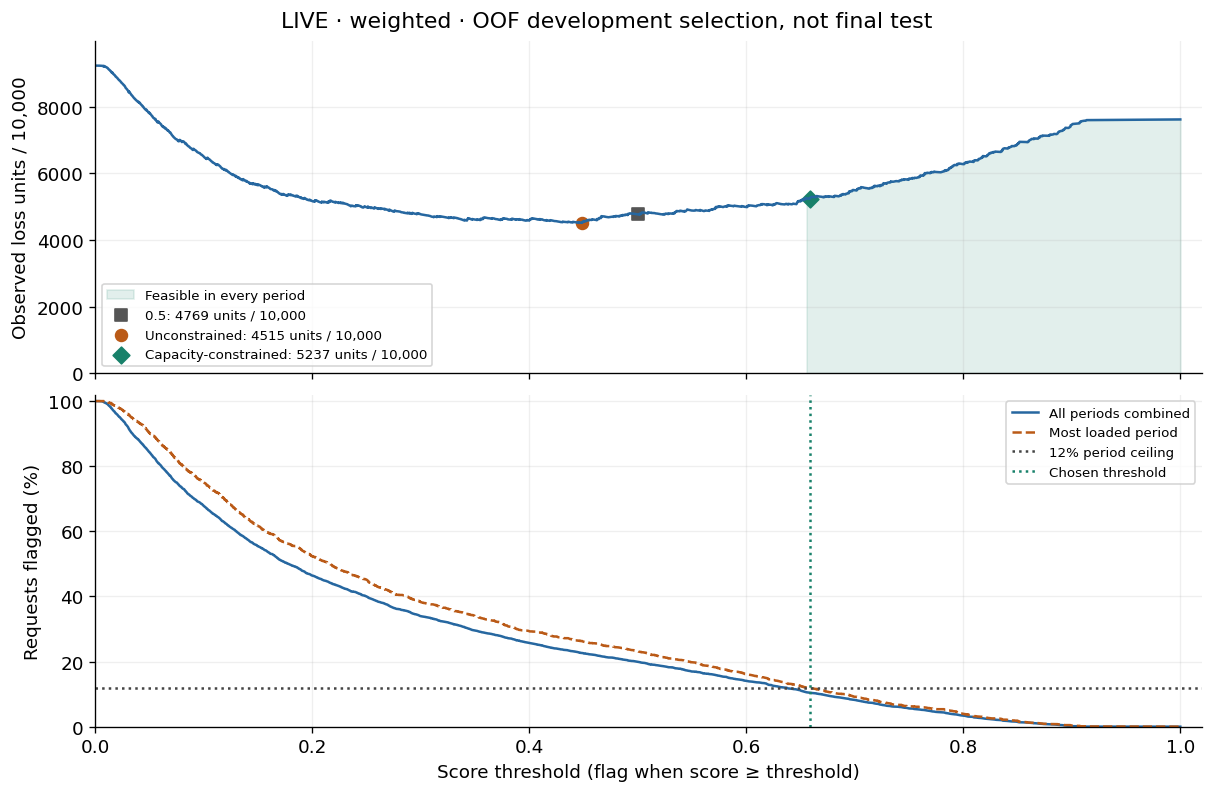

In [5]:
cost_curve = threshold_sweep(selected, policy)
unconstrained = select_threshold(cost_curve, constrained=False)
chosen = select_threshold(cost_curve, constrained=True)
default = cost_curve.loc[cost_curve.threshold.eq(.5)].iloc[0].to_dict()
operating_points = pd.DataFrame([{**point, "rule": name} for name, point in
    [("Default 0.5", default), ("Minimum loss, no capacity limit", unconstrained),
     ("Minimum loss, every-period capacity", chosen)]])
display(operating_points[["rule", "threshold", "tp", "fp", "fn", "tn", "recall", "precision",
    "flagged", "flag_fraction", "loss_units", "loss_units_per_10000", "capacity_feasible"]].round(4))
assert unconstrained["loss_units"] <= default["loss_units"]
if default["capacity_feasible"]:
    assert chosen["loss_units"] <= default["loss_units"]
periods = period_audit(selected, chosen["threshold"], policy)
assert periods.within_capacity.all()
delta = chosen["loss_units"] - default["loss_units"]
print(f"Constrained minus default loss: {delta:+.0f} educational units. Default feasible: {default['capacity_feasible']}")
print("Exact rule to preserve in JSON:", repr(chosen["threshold"]), "with >=")

fig, axes = plt.subplots(2, 1, figsize=(10, 6.5), sharex=True, constrained_layout=True)
axes[0].plot(cost_curve.threshold, cost_curve.loss_units_per_10000, color="#2667A0")
axes[0].fill_between(cost_curve.threshold, 0, cost_curve.loss_units_per_10000,
    where=cost_curve.capacity_feasible, color="#18816A", alpha=.12, label="Feasible in every period")
for label, point, marker, color in [("0.5", default, "s", "#555555"),
    ("Unconstrained", unconstrained, "o", "#BA5A17"), ("Capacity-constrained", chosen, "D", "#18816A")]:
    axes[0].scatter([point["threshold"]], [point["loss_units_per_10000"]], marker=marker, color=color, s=50,
        label=f"{label}: {point['loss_units_per_10000']:.0f} units / 10,000")
axes[0].set(ylabel="Observed loss units / 10,000", ylim=(0, cost_curve.loss_units_per_10000.max()*1.08))
axes[0].legend(fontsize=8)
axes[1].plot(cost_curve.threshold, cost_curve.flag_fraction*100, label="All periods combined", color="#2667A0")
axes[1].plot(cost_curve.threshold, cost_curve.max_period_flag_fraction*100, linestyle="--",
    label="Most loaded period", color="#BA5A17")
axes[1].axhline(policy.max_flag_fraction*100, color="#444444", linestyle=":", label="12% period ceiling")
axes[1].axvline(chosen["threshold"], color="#18816A", linestyle=":", label="Chosen threshold")
axes[1].set(xlabel="Score threshold (flag when score ≥ threshold)", ylabel="Requests flagged (%)", ylim=(0,102), xlim=(0,1.02))
axes[1].legend(fontsize=8)
fig.suptitle(f"{SOURCE} · {MODEL_FOR_DECISION} · OOF development selection, not final test")
fig.savefig(ARTIFACTS / "cost_curve.png", dpi=160)
plt.show()

In [6]:
display(periods)
sensitivity_rows = []
for fn_cost in [8., 10., 12.]:
    scenario_policy = replace(policy, false_negative_cost=fn_cost)
    scenario = select_threshold(threshold_sweep(selected, scenario_policy))
    sensitivity_rows.append({"FN_loss_units": fn_cost, "FP_loss_units": policy.false_positive_cost,
        "capacity_fraction": policy.max_flag_fraction, "threshold": scenario["threshold"],
        "flagged": scenario["flagged"], "recall": scenario["recall"],
        "loss_units": scenario["loss_units"], "capacity_feasible": scenario["capacity_feasible"], "source": SOURCE})
sensitivity = pd.DataFrame(sensitivity_rows)
display(sensitivity.round(4))
print("Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.")
print("Do not impose that formula on today's weighted raw scores.")

,fold,rows,capacity,flagged,flag_fraction,within_capacity,source
0,1,1632,195,137,0.083946,True,LIVE
1,2,1674,200,183,0.109319,True,LIVE
2,3,1733,207,206,0.118869,True,LIVE


,FN_loss_units,FP_loss_units,capacity_fraction,threshold,flagged,recall,loss_units,capacity_feasible,source
0,8.0,1,0.12,0.6583,526,0.4089,2185.0,True,LIVE
1,10.0,1,0.12,0.6583,526,0.4089,2639.0,True,LIVE
2,12.0,1,0.12,0.6583,526,0.4089,3093.0,True,LIVE


Theoretical threshold 1/11 ≈ 0.0909 requires calibrated probabilities, this loss matrix and no capacity limit.
Do not impose that formula on today's weighted raw scores.


,region,rows,negatives,positives,flagged,false_positives,true_positives,false_positive_rate,recall,low_negative_support,source
0,central,1184,1088,96,131,88,43,0.0809,0.4479,False,LIVE
1,western,1262,1158,104,132,96,36,0.0829,0.3462,False,LIVE
2,eastern,1295,1192,103,131,92,39,0.0772,0.3786,False,LIVE
3,other,1298,1217,81,132,93,39,0.0764,0.4815,False,LIVE


FPR gap (percentage points): 0.6484134519182061


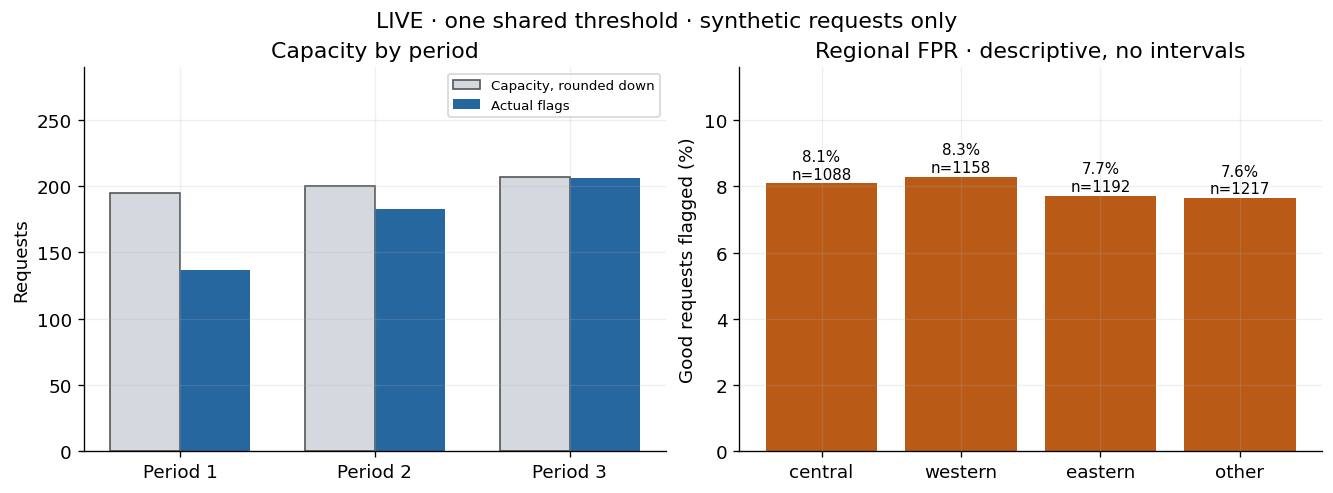

In [7]:
regions, gap_info = region_audit(selected, chosen["threshold"])
display(regions.round(4))
print("FPR gap (percentage points):", gap_info["fpr_gap_percentage_points"])
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
x = np.arange(len(periods))
axes[0].bar(x-.18, periods.capacity, .36, color="#D3D9DE", edgecolor="#555555", label="Capacity, rounded down")
axes[0].bar(x+.18, periods.flagged, .36, color="#2667A0", label="Actual flags")
axes[0].set(xticks=x, xticklabels=[f"Period {n}" for n in periods.fold], ylabel="Requests", title="Capacity by period")
axes[0].set_ylim(0, periods.capacity.max()*1.4)
axes[0].legend(fontsize=8)
axes[1].bar(regions.region, regions.false_positive_rate*100, color="#BA5A17")
axes[1].set(ylabel="Good requests flagged (%)", title="Regional FPR · descriptive, no intervals")
for i, row in enumerate(regions.itertuples()):
    if pd.notna(row.false_positive_rate):
        axes[1].text(i, row.false_positive_rate*100+.15, f"{row.false_positive_rate:.1%}\nn={row.negatives}", ha="center", fontsize=9)
axes[1].set_ylim(0, max(10, regions.false_positive_rate.max()*140))
fig.suptitle(f"{SOURCE} · one shared threshold · synthetic requests only")
fig.savefig(ARTIFACTS / "day3_capacity_regions.png", dpi=160)
plt.show()

In [8]:
responses = {
    "threshold_reason": "The threshold 0.6583 is the lowest-loss rule that keeps flags under the 12% capacity in every period (8.4%, 10.9% and 11.9%). The default 0.5 flags 19.9% of requests, so it is not feasible. The threshold also stays the same when the FN cost is 8, 10 or 12, so the decision is driven by capacity, not by the exact cost value.",
    "cost_capacity_tradeoff": "Respecting capacity costs 2,639 loss units, which is +236 vs the default 0.5 (2,403) and +364 vs the unconstrained minimum at 0.449 (2,275). Recall drops from 57.8% to 40.9%, but precision rises from 22.1% to 29.9% and false positives fall from 783 to 369, with 526 flags instead of 1,005.",
    "regional_gap": "With one shared threshold, the false-positive rate ranges from 7.6% (other) to 8.3% (western), a gap of 0.65 percentage points, and every region has more than 1,000 non-default cases. Recall varies more, from 34.6% (western) to 48.1% (other), so recall by region needs review and monitoring. This is a descriptive audit on synthetic data, not a fairness certification.",
    "limitations": "The threshold was chosen on the same OOF development rows, so the reported loss is optimistic and is not final-test performance. OOF covers only 5,039 of 10,000 rows (50.39%). The weighted scores are not calibrated probabilities. Period 3 is at 11.9%, very close to the 12% ceiling, so future volume changes could break capacity. The data is synthetic.",
    "why_accuracy_misleads": "Only 7.6% of requests default. Flagging nobody gives 92.4% accuracy with 0% recall, and the unweighted model at 0.5 has 92.6% accuracy but catches only 12.5% of defaults. Accuracy rewards ignoring the rare class, so we use AP, recall, precision, flags and loss instead.",
    "why_oof": "Training predictions come from models that already saw those labels, so they are over-confident and a threshold chosen on them would be too optimistic. OOF predictions come from models that did not see those rows, so they behave more like new applications and give a more honest basis for choosing the threshold."
}
checkpoint = reflection_check(responses, SOURCE)
print(checkpoint["status"], "| missing:", checkpoint["missing"])

READY_FOR_REVIEW | missing: []


In [9]:
def json_safe(value):
    if isinstance(value, dict): return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)): return [json_safe(v) for v in value]
    if isinstance(value, np.generic): value = value.item()
    if isinstance(value, float) and not np.isfinite(value): return None
    return value

checkpoint = reflection_check(responses, SOURCE)
status = "TECHNICAL_READY" if SOURCE == "LIVE" else "EXAMPLE_ONLY_NOT_SUBMITTABLE"
pooled_ap = float(average_precision_score(selected[TARGET], selected.probability))
threshold_metrics = {"source": SOURCE, "technical_status": status, "strategy": MODEL_FOR_DECISION,
    "policy": asdict(policy), "unit": "educational_loss_unit", "comparison_operator": ">=",
    "capacity_scope": "every validation period; floor(fraction * period_rows)",
    "chosen": chosen, "unconstrained": unconstrained, "default_0_5": default,
    "loss_change_vs_default": delta, "pooled_oof_ap": pooled_ap, "regional_audit": gap_info,
    "coverage": coverage, "selection_status": "OOF development selection; not an independent final test"}
membership = train[["application_id", "application_date"]].copy()
membership["role"], membership["fold"] = "warmup_no_oof", 0
for fold in folds:
    membership.loc[fold["valid"], "role"] = "eligible_oof"
    membership.loc[fold["valid"], "fold"] = fold["audit"]["fold"]
membership["source"] = SOURCE
decisions = selected.copy()
decisions["review_flag"] = flag_at(selected.probability, chosen["threshold"]).astype(int)
csv_outputs = {"day3_model_report.csv": model_report, "day3_model_comparison.csv": comparison,
    "day3_oof_predictions.csv": oof, "day3_oof_coverage.csv": membership, "threshold_sweep.csv": cost_curve,
    "day3_period_capacity.csv": periods, "day3_region_audit.csv": regions,
    "day3_cost_sensitivity.csv": sensitivity, "day3_review_flags.csv": decisions}
for filename, table in csv_outputs.items(): table.to_csv(ARTIFACTS / filename, index=False)
run = {"technical_status": status, "learner_status": checkpoint["status"], "source": SOURCE,
    "requested_config": asdict(config), "effective_config": effective_config, "assessment_mode": ASSESSMENT_MODE,
    "data_revision": COURSE_REVISION, "lab_revision": LAB_REVISION, "support_sha256": SUPPORT_HASHES,
    "day2_revision": DAY2_REVISION, "day2_sha256": DAY2_SHA256, "manifest_sha256": MANIFEST_SHA256,
    "training_data_sha256": hashlib.sha256((ROOT / "data/tamweel_train.csv").read_bytes()).hexdigest(),
    "python": platform.python_version(), "elapsed_seconds": round(time.perf_counter()-RUN_STARTED,2),
    "coverage": coverage, "challenge_used_for_modeling": False, "no_automatic_grade": True}
if IN_COLAB:
    import resource
    run["peak_process_memory_mib"] = round(resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024,1)
json_outputs = {"threshold_metrics.json": threshold_metrics, "day3_provenance.json": provenance,
    "day3_reflection.json": {"source": SOURCE, "responses": responses, "checkpoint": checkpoint}, "day3_run.json": run}
for filename, payload in json_outputs.items():
    (ARTIFACTS / filename).write_text(json.dumps(json_safe(payload), ensure_ascii=False, indent=2, allow_nan=False), encoding="utf-8")

answer = lambda key: responses[key].strip() or "[اكتب تفسيرك من نتائجك هنا]"
rate_text = lambda value: f"{value:.2%}" if pd.notna(value) else "غير معرّفة لغياب المقام"
card_status = ("مثال تعليمي غير صالح للتسليم كتجربة شخصية" if SOURCE != "LIVE" else
               "مسودة — أكمل تفسيرك" if checkpoint["missing"] else "جاهزة للمراجعة؛ لا تعني اعتمادًا أو درجة")
card = f"""# بطاقة قرارك — Tamweel Lite

**الحالة:** {card_status}
**مصدر الأرقام:** {SOURCE} · **الاستراتيجية:** {MODEL_FOR_DECISION} · **الصفوف:** {len(selected):,} OOF

**المهمة:** الفئة الموجبة `default_within_90d=1` تعني حدث تعثر اصطناعي خلال90 يومًا بعد الطلب. كل طية تحقق طلبات لاحقة، وتستبعد عملاءها من التدريب وتشترط نضج نتيجة التدريب قبل بدايتها. المعرّفات والتاريخ خارج المدخلات.

| الدليل | القيمة |
|---|---:|
| العتبة المقيدة، بالقيمة الكاملة | {repr(chosen['threshold'])} |
| عتبة أقل خسارة دون قيد | {repr(unconstrained['threshold'])} |
| Recall | {rate_text(chosen['recall'])} |
| Precision | {rate_text(chosen['precision'])} |
| AP مجمع منOOF | {pooled_ap:.4f} |
| الإشارات | {chosen['flagged']:,} من {len(selected):,} |
| FN / FP | {chosen['fn']} / {chosen['fp']} |
| الخسارة التعليمية | {chosen['loss_units']:.0f} وحدة |
| خسارة0.5 | {default['loss_units']:.0f} وحدة؛ ضمن السعة: {default['capacity_feasible']} |
| التغير عن0.5 | {delta:+.0f} وحدة؛ الموجب زيادة |
| خسارة لكل10,000 طلب، تطبيع حسابي | {chosen['loss_units_per_10000']:.2f} وحدة |
| فجوة معدل الإنذار الخاطئ بين المناطق | {gap_info['fpr_gap_percentage_points']:.3f} نقطة مئوية |

**القاعدة:** درجة ≥ {repr(chosen['threshold'])} تعني إشارة مراجعة داخل التمرين؛ غير ذلك بلا إشارة. لا تتخذ موافقة أو رفض تمويل حقيقي. احفظ الدقة الكاملة؛ تقريب العتبة قد يغيّر حجم الطابور.

**السياسة:** FN={policy.false_negative_cost:g} وFP={policy.false_positive_cost:g} وحدات تعليمية، وسعة {policy.max_flag_fraction:.0%} لكل فترة بعد التقريب لأسفل. ليست ريالات فعلية أو رسوم أدوات أو خصمًا من الدرجة.

**دليل السعة:** {', '.join(f"الفترة {int(row.fold)}: {int(row.flagged)}/{int(row.capacity)}" for row in periods.itertuples())}.

## لماذا اخترت هذه العتبة؟
{answer('threshold_reason')}

## الخسارة والسعة
{answer('cost_capacity_tradeoff')}

## فرق المناطق وما يحتاج إلى مراجعة
{answer('regional_gap')}

## حدود النتيجة
{answer('limitations')}

OOF تغطي {coverage['whole_data_coverage']:.2%} من التدريب و100% من الصفوف المؤهلة؛ {coverage['warmup_without_oof']:,} صفًا تمهيديًا بلا تنبؤ. اختيار العتبة وتقدير خسارتها هنا يستخدمان أهدافOOF نفسها؛ هذه نتيجة تطوير لا اختبار نهائي. لم نستخدم التحدي. المقارنة الجغرافية وصفية وليست شهادة عدالة، والأوزان لا تضمن معايرة الدرجات.

## سؤالك الأول: لماذا قد تخدعكAccuracy؟
{answer('why_accuracy_misleads')}

## سؤالك الثاني: لماذا تختار علىOOF؟
{answer('why_oof')}

أدلتك في `artifacts/threshold_metrics.json` و`day3_period_capacity.csv` و`day3_region_audit.csv` و`day3_cost_sensitivity.csv` و`cost_curve.png`. الحساسية سيناريوهات ±20% لخسارةFN، وليست فترات ثقة. راجع السعة والمعايرة عند تغير البيانات؛ لا تفترض ثباتهما مستقبلًا.
"""
(REPORTS / "DECISION_CARD.md").write_text(card, encoding="utf-8")
artifact_files = list(csv_outputs) + list(json_outputs) + ["cost_curve.png", "day3_roc_pr.png", "day3_capacity_regions.png", "environment.json"]
with zipfile.ZipFile(ARTIFACTS / "day3_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as bundle:
    for filename in artifact_files:
        bundle.write(ARTIFACTS / filename, "artifacts/" + filename)
    bundle.write(REPORTS / "DECISION_CARD.md", "reports/DECISION_CARD.md")
print(f"{status} | {checkpoint['status']} | {SOURCE} | {run['elapsed_seconds']} seconds | CPU")
print(f"Saved {len(artifact_files)+1} files in day3_artifacts.zip — complete your reasoning and download.")

TECHNICAL_READY | READY_FOR_REVIEW | LIVE | 22.01 seconds | CPU
Saved 18 files in day3_artifacts.zip — complete your reasoning and download.


### Day 3 summary
**Goal:** turn model scores into a review decision tied to cost, capacity and fairness.

| Rule | Threshold | Recall | Precision | Flags | Loss | Capacity |
|---|---|---|---|---|---|---|
| Default | 0.500 | 57.8% | 22.1% | 1,005 (19.9%) | 2,403 | ❌ |
| Lowest loss, no limit | 0.449 | 64.1% | 21.6% | 1,141 (22.6%) | 2,275 | ❌ |
| **Chosen (capacity-safe)** | **0.6583** | **40.9%** | **29.9%** | **526 (10.4%)** | **2,639** | ✅ |

- **Policy:** loss = 10 × FN + 1 × FP, and at most 12% flagged in every period.
- **Imbalance:** unweighted, weighted and oversampled models ranked almost the same (AP 0.309–0.316); weights move the threshold, not the ranking.
- **Accuracy trap:** flagging nobody gives 92.4% accuracy with 0% recall.
- **Capacity:** periods at 8.4%, 10.9% and 11.9%; the threshold stays 0.6583 for FN cost 8, 10 or 12.
- **Regions:** FPR gap 0.65 pp (7.6%–8.3%), but recall ranges 34.6%–48.1% and needs monitoring.
- **Limitation:** threshold chosen on the same OOF rows (optimistic); weighted scores are not calibrated yet (Day 4).